In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
Exercício Pratico 1

In [2]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

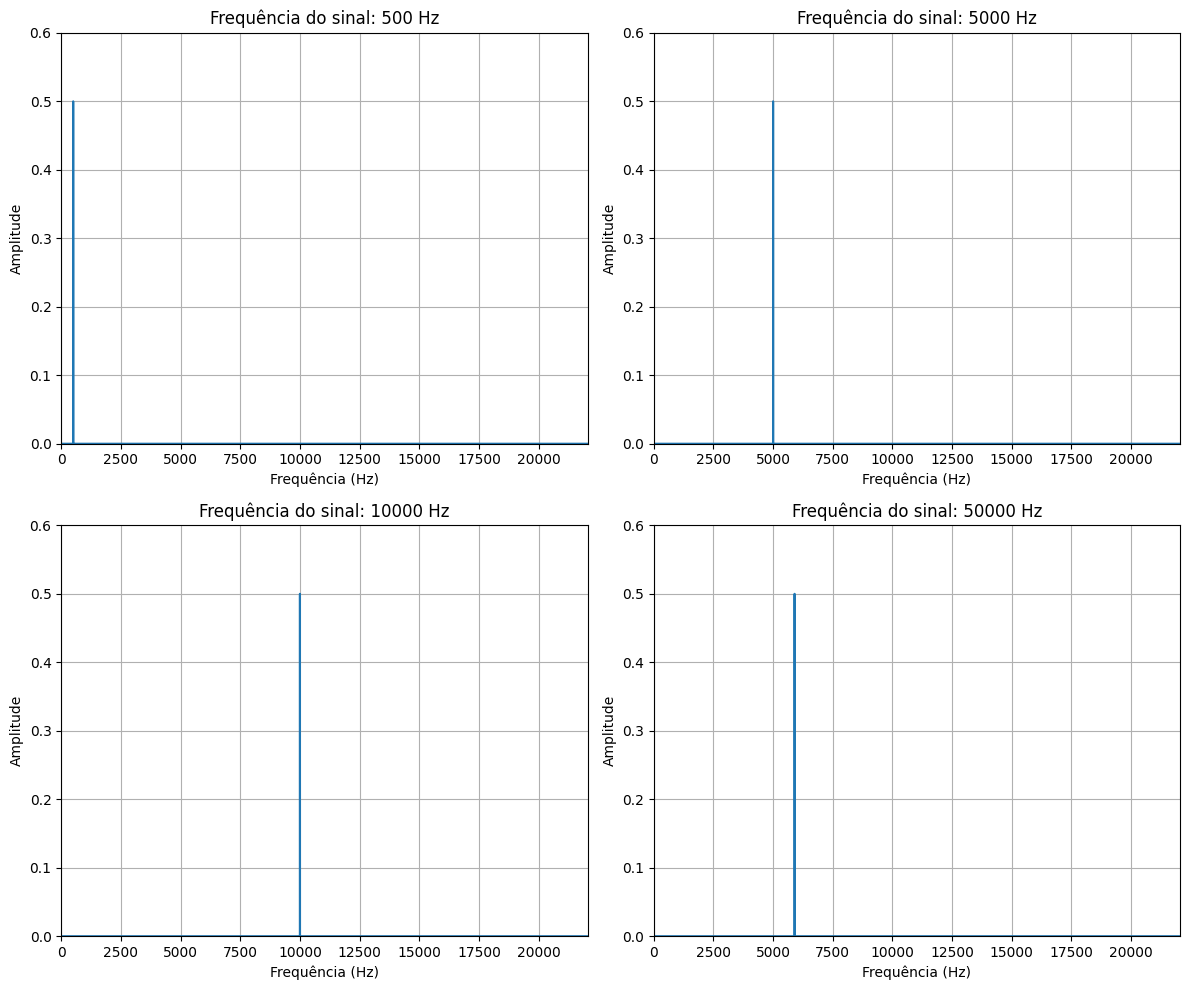

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Função fornecida
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency
    yf = fft(signal)
    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)
    return xf, amplitudes

# Parâmetros
fs = 44100  # Hz
duration = 1.0  # 1 segundo de sinal
t = np.linspace(0.0, duration, int(fs * duration), endpoint=False)

# Frequências a testar
frequencies = [500, 5000, 10000, 50000]

plt.figure(figsize=(12, 10))

for i, f in enumerate(frequencies):
    # Gerar sinal cosseno
    signal = np.cos(2 * np.pi * f * t)

    # Calcular espectro
    freqs, amps = calculate_spectrum(signal, fs, single_sided=True)

    # Plotar
    plt.subplot(2, 2, i+1)
    plt.plot(freqs, amps)
    plt.title(f'Frequência do sinal: {f} Hz')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.xlim(0, fs/2)
    plt.ylim(0, 0.6)

plt.tight_layout()
plt.show()

In [ ]:
comentarios (Fazer depois)

In [ ]:
exercício 2

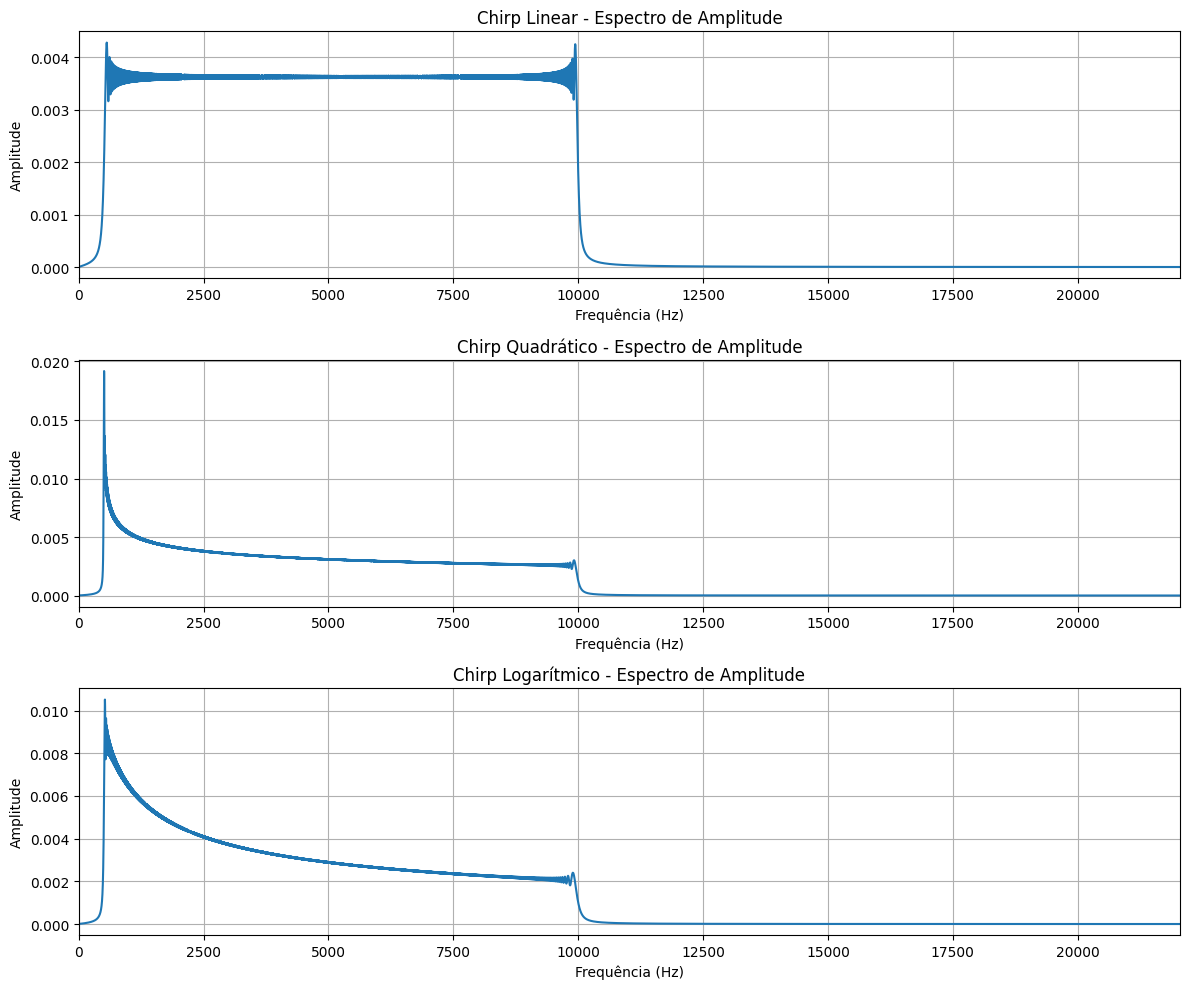

In [9]:
#deepseek

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import chirp

# Função fornecida
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal)
    T = 1.0 / sampling_frequency
    yf = fft(signal)
    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)
    return xf, amplitudes

# Parâmetros do chirp
fs = 44100  # Hz
duration = 2.0  # segundos
t = np.linspace(0.0, duration, int(fs * duration), endpoint=False)

f0 = 500   # Hz
f1 = 10000 # Hz

# Gerar os três tipos de chirp
signal_linear = chirp(t, f0=f0, f1=f1, t1=duration, method='linear')
signal_quadratic = chirp(t, f0=f0, f1=f1, t1=duration, method='quadratic')
signal_logarithmic = chirp(t, f0=f0, f1=f1, t1=duration, method='logarithmic')

# Calcular espectros
freqs_lin, amps_lin = calculate_spectrum(signal_linear, fs, single_sided=True)
freqs_quad, amps_quad = calculate_spectrum(signal_quadratic, fs, single_sided=True)
freqs_log, amps_log = calculate_spectrum(signal_logarithmic, fs, single_sided=True)

# Plotar os espectros
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(freqs_lin, amps_lin)
plt.title('Chirp Linear - Espectro de Amplitude')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs/2)

plt.subplot(3, 1, 2)
plt.plot(freqs_quad, amps_quad)
plt.title('Chirp Quadrático - Espectro de Amplitude')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs/2)

plt.subplot(3, 1, 3)
plt.plot(freqs_log, amps_log)
plt.title('Chirp Logarítmico - Espectro de Amplitude')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs/2)

plt.tight_layout()
plt.show()

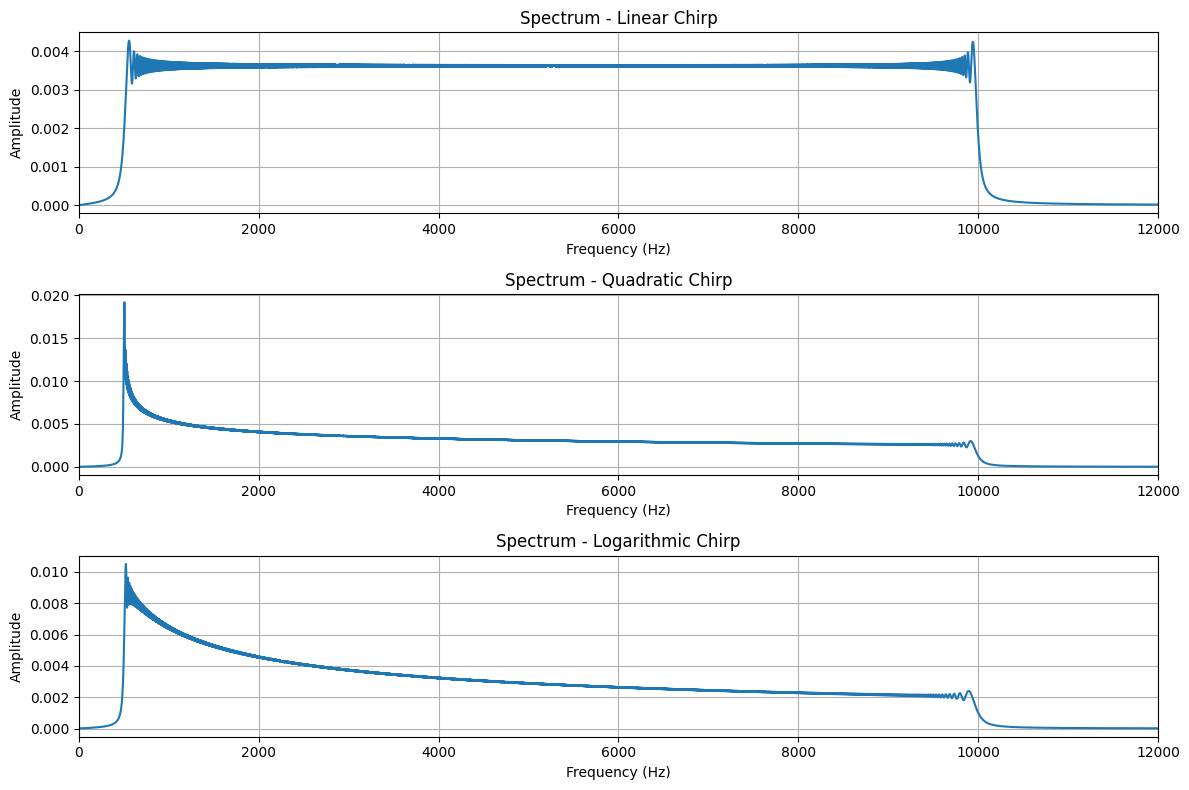

In [8]:


#gpt

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp

fs = 44100        # frequência de amostragem
duration = 2      # duração do chirp
f0 = 500          # frequência inicial
f1 = 10000        # frequência final

t = np.linspace(0, duration, int(fs*duration), endpoint=False)

chirp_linear = chirp(t, f0=f0, f1=f1, t1=duration, method='linear')
chirp_quadratic = chirp(t, f0=f0, f1=f1, t1=duration, method='quadratic')
chirp_log = chirp(t, f0=f0, f1=f1, t1=duration, method='logarithmic')


freq_lin, amp_lin = calculate_spectrum(chirp_linear, fs, single_sided=True)

freq_quad, amp_quad = calculate_spectrum(chirp_quadratic, fs, single_sided=True)

freq_log, amp_log = calculate_spectrum(chirp_log, fs, single_sided=True)

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(freq_lin, amp_lin)
plt.title("Spectrum - Linear Chirp")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0,12000)
plt.grid()

plt.subplot(3,1,2)
plt.plot(freq_quad, amp_quad)
plt.title("Spectrum - Quadratic Chirp")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0,12000)
plt.grid()

plt.subplot(3,1,3)
plt.plot(freq_log, amp_log)
plt.title("Spectrum - Logarithmic Chirp")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0,12000)
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
Comentarios

In [ ]:
Exercicio 3

In [12]:
# 1. Importar bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.io import wavfile
from google.colab import files
import io

print("Bibliotecas importadas com sucesso!")
# Upload do arquivo de áudio
print("Faça o upload do arquivo de áudio:")
uploaded = files.upload()

# Obter o nome do arquivo
filename = list(uploaded.keys())[0]
print(f"\nArquivo carregado: {filename}")

# Carregar o áudio
sample_rate, audio_data = wavfile.read(filename)

# Informações do áudio
print(f"\nTaxa de amostragem original: {sample_rate} Hz")
print(f"Número de amostras: {len(audio_data)}")
print(f"Duração: {len(audio_data)/sample_rate:.2f} segundos")

Bibliotecas importadas com sucesso!
Faça o upload do arquivo de áudio:


Saving handel.wav to handel.wav

Arquivo carregado: handel.wav

Taxa de amostragem original: 8192 Hz
Número de amostras: 73113
Duração: 8.92 segundos


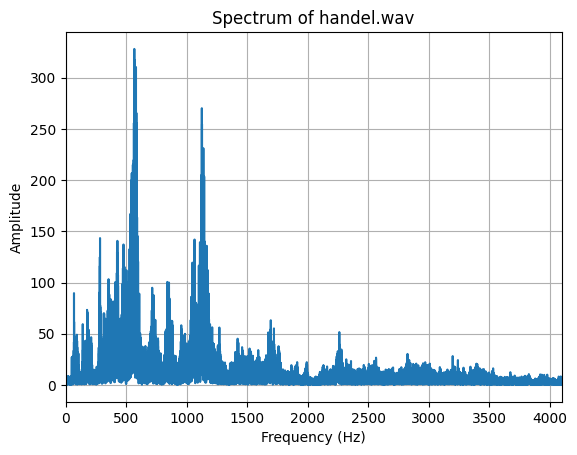

In [13]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

# Ler o arquivo
sampling_frequency, signal = wavfile.read("handel.wav")

# Se for estéreo, pegar um canal
if len(signal.shape) > 1:
    signal = signal[:,0]

# Calcular espectro
frequencies, amplitudes = calculate_spectrum(signal, sampling_frequency)

# Plotar
plt.plot(frequencies, amplitudes)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Spectrum of handel.wav")
plt.xlim(0, sampling_frequency/2)
plt.grid()
plt.show()


In [ ]:
comentarios

In [ ]:
exercicio 4

In [15]:
import numpy as np
from scipy.io import wavfile
from google.colab import files

# upload do arquivo
uploaded = files.upload()

# ler o arquivo
sampling_frequency, signal = wavfile.read("handel.wav")

# se for estéreo, pegar um canal
if len(signal.shape) > 1:
    signal = signal[:,0]

# função de subamostragem
def downsample_signal(signal, M):
    return signal[::M]

# fator de subamostragem
M = 2

# aplicar subamostragem
signal_downsampled = downsample_signal(signal, M)

# nova taxa de amostragem
new_sampling_frequency = sampling_frequency / M

print("Fs original:", sampling_frequency)
print("Fs novo:", new_sampling_frequency)
print("Número de amostras original:", len(signal))
print("Número de amostras subamostrado:", len(signal_downsampled))


Saving handel.wav to handel (2).wav
Fs original: 8192
Fs novo: 4096.0
Número de amostras original: 73113
Número de amostras subamostrado: 36557


In [ ]:
b), c), d)

Saving handel.wav to handel (3).wav
Subamostragem com M = 2


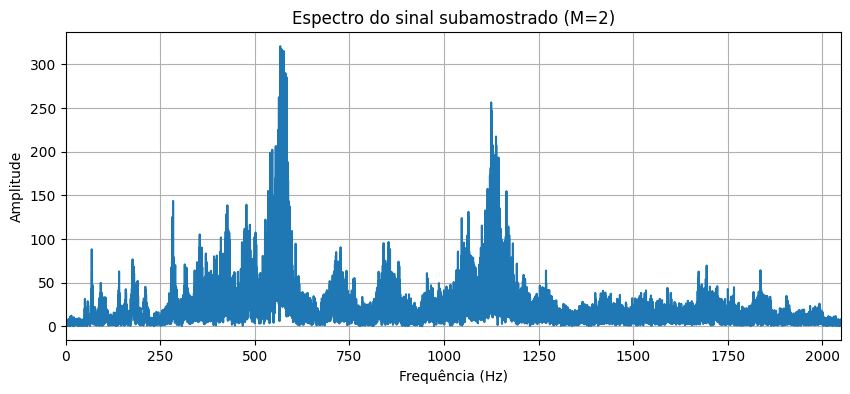

Subamostragem com M = 4


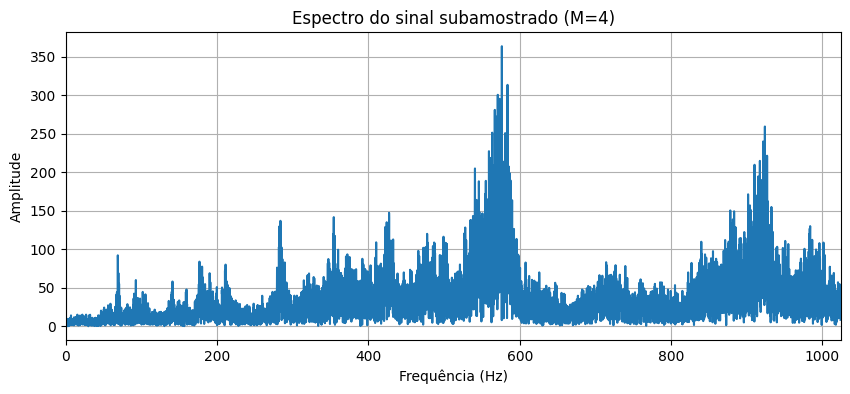

Subamostragem com M = 8


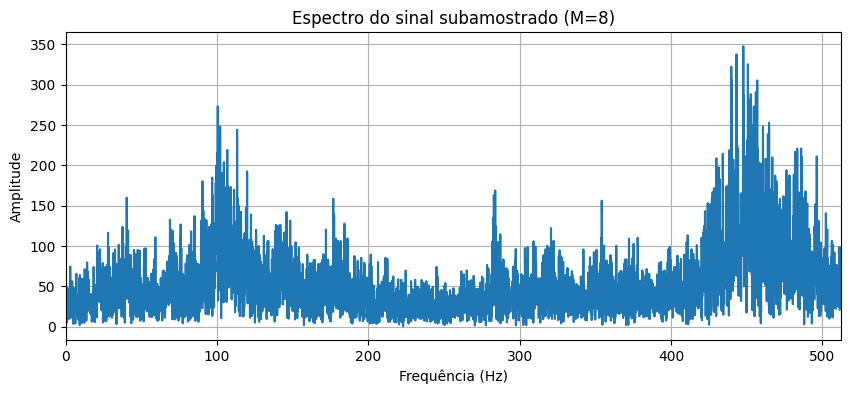

In [16]:
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.io import wavfile
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import Audio

# Upload do arquivo
uploaded = files.upload()

# Ler o arquivo
sampling_frequency, signal = wavfile.read("handel.wav")

# Se for estéreo, usar apenas um canal
if len(signal.shape) > 1:
    signal = signal[:,0]

# -------------------------------
# Função de subamostragem
# -------------------------------
def downsample_signal(signal, M):
    return signal[::M]

# -------------------------------
# Função de espectro (mesma do exercício)
# -------------------------------
def calculate_spectrum(signal, sampling_frequency, single_sided=True):

    N = len(signal)
    T = 1.0 / sampling_frequency

    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2]
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T)
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# -------------------------------
# Fatores de subamostragem
# -------------------------------
M_values = [2,4,8]

for M in M_values:

    print("Subamostragem com M =", M)

    # (b) Subamostrar
    signal_down = downsample_signal(signal, M)

    # nova frequência de amostragem
    new_fs = sampling_frequency / M

    # (c) Calcular espectro
    freq, amp = calculate_spectrum(signal_down, new_fs)

    # Plotar espectro
    plt.figure(figsize=(10,4))
    plt.plot(freq, amp)
    plt.title(f"Espectro do sinal subamostrado (M={M})")
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Amplitude")
    plt.xlim(0, new_fs/2)
    plt.grid(True)
    plt.show()

    # (d) Ouvir sinal
    display(Audio(signal_down, rate=int(new_fs)))
